# K-Means 기반 행정동 상권 군집 분석

행정동-분기 단위 데이터를 이용해 유동인구, 매출액, 매출건수, 프랜차이즈 침투율 기준으로 상권 유형을 분류한다.

## 1. 라이브러리 및 기본 설정

In [105]:
from pathlib import Path
import os

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", None)

DATA_PATH = Path("../data/ML용_행정동_분기_마스터.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/ML용_행정동_분기_마스터.csv")

OUTPUT_PATH = DATA_PATH.parent / "ML용_kmeans_result_4vars.csv"

FEATURES = [
    "floating_pop",
    "sales_amt",
    "sales_cnt",
    "franchise_ratio",
]

N_CLUSTERS = 4
RANDOM_STATE = 42

## 2. 데이터 로드 및 분석 변수 선택

In [106]:
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.head()

,base_quarter,year,quarter,adm_dong_cd,adm_dong_nm,gu,resident_pop_mean,resident_pop_end,household_cnt_mean,household_size_mean,...,avg_ticket_quarter_z,store_mer_cnt_quarter_z,franchise_ratio_quarter_z,industry_diversity_H_quarter_z,bus_board_cnt_quarter_z,bus_alight_cnt_quarter_z,subway_board_cnt_quarter_z,subway_alight_cnt_quarter_z,전입_고소득층_비율_quarter_z,전입_소득수준_가중평균_quarter_z
0,2023Q1,2023,1,41131510,신흥1동,수정구,13124.000000,13106,7925.333333,1.656667,...,-0.369428,-0.259909,-0.438696,-0.454983,-0.466373,-0.486555,-0.040622,-0.009277,-1.196207,-1.108073
1,2023Q2,2023,2,41131510,신흥1동,수정구,13035.333333,13017,7888.000000,1.653333,...,-0.335069,-0.262380,-0.456131,-0.598613,-0.489212,-0.511343,-0.044528,-0.011092,-1.198373,-1.143744
2,2023Q3,2023,3,41131510,신흥1동,수정구,12902.000000,12847,7826.666667,1.650000,...,-0.424146,-0.273074,-0.416127,-0.540826,-0.477402,-0.496206,-0.030965,0.004755,-1.293458,-1.195199
3,2023Q4,2023,4,41131510,신흥1동,수정구,12735.000000,12665,7739.333333,1.646667,...,-0.390032,-0.277862,-0.444681,-0.700237,-0.485774,-0.507697,-0.048626,-0.014374,-1.281535,-1.199091
4,2024Q1,2024,1,41131510,신흥1동,수정구,12618.000000,12568,7699.333333,1.640000,...,-0.433344,-0.267626,-0.453348,-0.645423,-0.489043,-0.503332,-0.034262,-0.006554,-1.313437,-1.244574


In [107]:
ml_df = df[
    [
        "base_quarter",
        "adm_dong_nm",
        "gu",
        *FEATURES,
    ]
].copy()

ml_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio
0,2023Q1,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482
1,2023Q2,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364
2,2023Q3,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809
3,2023Q4,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021
4,2024Q1,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544


In [108]:
ml_df.info()
ml_df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   base_quarter     600 non-null    str    
 1   adm_dong_nm      600 non-null    str    
 2   gu               600 non-null    str    
 3   floating_pop     600 non-null    float64
 4   sales_amt        600 non-null    float64
 5   sales_cnt        600 non-null    float64
 6   franchise_ratio  600 non-null    float64
dtypes: float64(4), str(3)
memory usage: 47.5 KB


base_quarter       0
adm_dong_nm        0
gu                 0
floating_pop       0
sales_amt          0
sales_cnt          0
franchise_ratio    0
dtype: int64

## 3. 스케일링 및 군집 수 검토

In [109]:
X = ml_df[FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

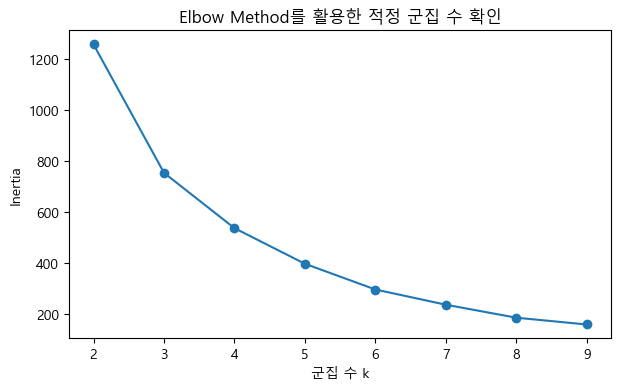

In [110]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method를 활용한 적정 군집 수 확인")
plt.xlabel("군집 수 k")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.show()

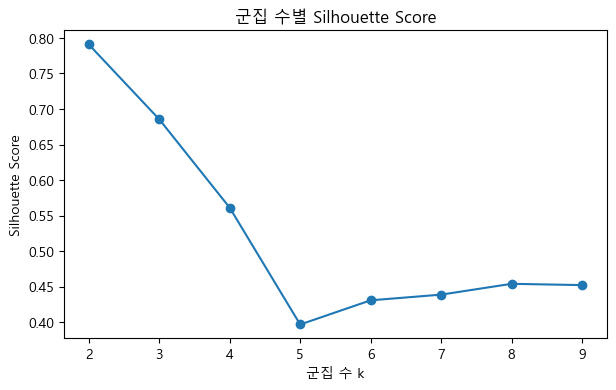

In [111]:
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(7, 4))
plt.plot(k_range, silhouette_scores, marker="o")
plt.title("군집 수별 Silhouette Score")
plt.xlabel("군집 수 k")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.show()

Silhouette Score만 보면 k=2가 가장 높게 나타났지만, k=2는 상권을 너무 단순하게 일반형과 특이형 정도로만 나누는 한계가 있었다. 본 분석에서는 백현동의 프랜차이즈 침투형, 정자1동의 초고활성 대형 상권형, 중상위 활성 상권형, 일반/기준 상권형을 구분하기 위해 해석 가능성을 고려하여 k=4를 사용하였다.

## 4. 최종 K-Means 군집 생성

Elbow와 Silhouette 결과를 확인한 뒤 최종 군집 수는 4개로 고정한다.

In [112]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
ml_df["cluster"] = kmeans.fit_predict(X_scaled)

ml_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster
0,2023Q1,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482,0
1,2023Q2,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364,0
2,2023Q3,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809,0
3,2023Q4,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021,0
4,2024Q1,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544,0


## 5. 군집별 특성 확인

In [113]:
cluster_counts = ml_df["cluster"].value_counts().sort_index()
cluster_counts

cluster
0    479
1     12
2     97
3     12
Name: count, dtype: int64

In [114]:
cluster_summary = ml_df.groupby("cluster")[FEATURES].mean()
display(cluster_summary)

,floating_pop,sales_amt,sales_cnt,franchise_ratio
cluster,,,,
0,1.784626e+06,9.615703e+10,1.977174e+06,5.423618
1,4.613867e+06,3.585017e+12,1.196821e+08,16.960166
2,5.913653e+06,4.604991e+11,1.030029e+07,8.163951
3,6.434185e+06,1.331472e+13,2.278689e+08,8.459322


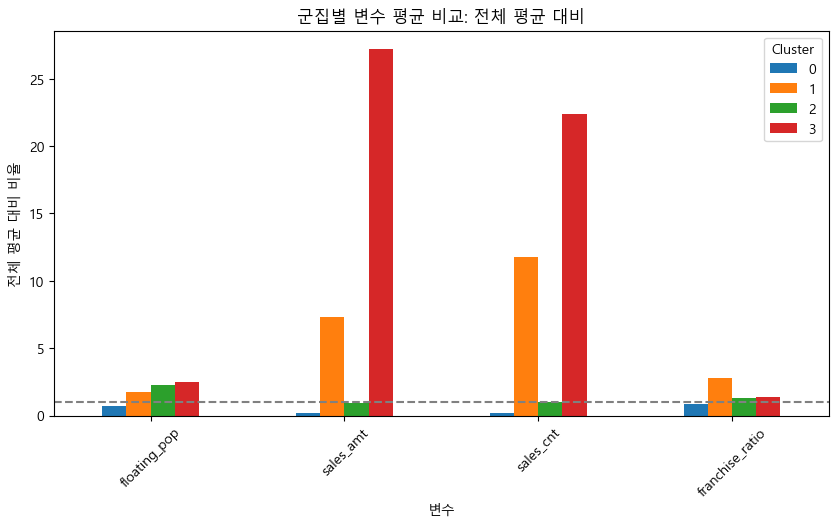

In [115]:
cluster_compare = cluster_summary / ml_df[FEATURES].mean()

ax = cluster_compare.T.plot(kind="bar", figsize=(10, 5))
ax.axhline(1, linestyle="--", color="gray")
ax.set_title("군집별 변수 평균 비교: 전체 평균 대비")
ax.set_xlabel("변수")
ax.set_ylabel("전체 평균 대비 비율")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Cluster")
plt.show()

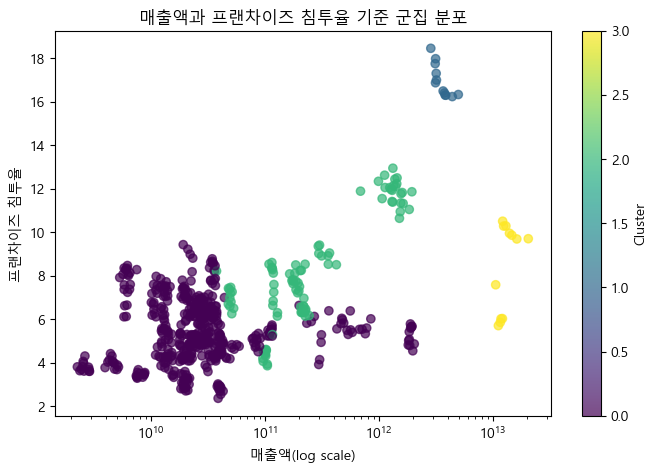

In [116]:
plt.figure(figsize=(8, 5))
plt.scatter(
    ml_df["sales_amt"],
    ml_df["franchise_ratio"],
    c=ml_df["cluster"],
    alpha=0.7,
)

plt.xscale("log")
plt.title("매출액과 프랜차이즈 침투율 기준 군집 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("프랜차이즈 침투율")
plt.colorbar(label="Cluster")
plt.show()

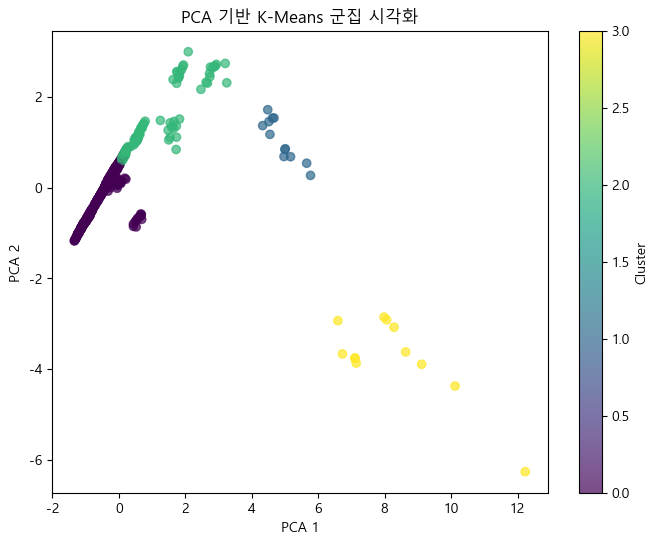

In [117]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

ml_df["pca1"] = X_pca[:, 0]
ml_df["pca2"] = X_pca[:, 1]

# 시각화용 로그 변환: 원본 K-Means 결과는 유지하고, 그림에서만 극단값 눌림을 완화한다.
X_vis = ml_df[FEATURES].copy()
for col in ["floating_pop", "sales_amt", "sales_cnt"]:
    X_vis[col] = np.log1p(X_vis[col])

X_vis_scaled = StandardScaler().fit_transform(X_vis)
pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_vis_scaled)

ml_df["pca_log1"] = X_pca_vis[:, 0]
ml_df["pca_log2"] = X_pca_vis[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = axes[0].scatter(
    ml_df["pca1"],
    ml_df["pca2"],
    c=ml_df["cluster"],
    alpha=0.65,
    s=36,
)
axes[0].set_title("원본 변수 PCA 시각화")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].grid(alpha=0.25)

scatter2 = axes[1].scatter(
    ml_df["pca_log1"],
    ml_df["pca_log2"],
    c=ml_df["cluster"],
    alpha=0.65,
    s=36,
)
axes[1].set_title("로그 변환 후 PCA 시각화")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].grid(alpha=0.25)

fig.colorbar(scatter2, ax=axes, label="Cluster", shrink=0.85)
plt.show()

print("원본 PCA 2축 설명력:", round(pca.explained_variance_ratio_.sum(), 4))
print("로그 변환 PCA 2축 설명력:", round(pca_vis.explained_variance_ratio_.sum(), 4))

| cluster | 특징 | 해석 이름 |
| ------: | --- | --- |
| 0 | 유동인구, 매출액, 매출건수, 프랜차이즈 침투율 모두 가장 낮음 | **일반/저활력 상권형** |
| 1 | 매출액·매출건수가 높고, 특히 프랜차이즈 침투율이 압도적으로 높음 | **프랜차이즈 침투 고위험형** |
| 2 | 유동인구는 높지만 매출액·매출건수는 cluster 1, 3보다 낮음 | **중상위 활성 상권형** |
| 3 | 유동인구, 매출액, 매출건수 모두 최고 수준 | **초고활성 대형 상권형** |

cluster 1은 평균 프랜차이즈 침투율이 약 16.96으로 가장 높아 젠트리피케이션 위험 후보군으로 볼 수 있다. 정자1동이 포함된 cluster 3은 프랜차이즈 침투율보다는 매출액과 매출건수가 압도적으로 높은 초고활성 대형 상권에 가깝다.

In [118]:
CLUSTER_LABELS = {
    0: "일반/기준 상권형",
    1: "프랜차이즈 침투 고위험형",
    2: "중상위 활성 상권형",
    3: "초고활성 대형 상권형",
}

ml_df["cluster_label"] = ml_df["cluster"].map(CLUSTER_LABELS)

ml_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster,pca1,pca2,cluster_label
0,2023Q1,신흥1동,수정구,781803.43,2.533850e+10,999168.0,4.893482,0,-0.875671,-0.591910,일반/기준 상권형
1,2023Q2,신흥1동,수정구,808998.65,2.648371e+10,1092318.0,4.843364,0,-0.876821,-0.596346,일반/기준 상권형
2,2023Q3,신흥1동,수정구,807881.77,2.583415e+10,1113248.0,5.156809,0,-0.822820,-0.528017,일반/기준 상권형
3,2023Q4,신흥1동,수정구,860145.94,2.626346e+10,1072653.0,5.164021,0,-0.811157,-0.511109,일반/기준 상권형
4,2024Q1,신흥1동,수정구,779105.37,2.431509e+10,1043582.0,5.277544,0,-0.809547,-0.508711,일반/기준 상권형


## 6. 행정동별 군집 확인

In [119]:
dong_cluster = (
    ml_df.groupby(["adm_dong_nm", "gu", "cluster", "cluster_label"])
    .size()
    .reset_index(name="quarter_count")
    .sort_values(["cluster", "quarter_count"], ascending=[True, False])
)

display(dong_cluster)

,adm_dong_nm,gu,cluster,cluster_label,quarter_count
0,고등동,수정구,0,일반/기준 상권형,12
1,구미1동,분당구,0,일반/기준 상권형,12
5,금광1동,중원구,0,일반/기준 상권형,12
6,금광2동,중원구,0,일반/기준 상권형,12
7,단대동,수정구,0,일반/기준 상권형,12
8,도촌동,중원구,0,일반/기준 상권형,12
10,복정동,수정구,0,일반/기준 상권형,12
11,분당동,분당구,0,일반/기준 상권형,12
12,산성동,수정구,0,일반/기준 상권형,12
14,상대원1동,중원구,0,일반/기준 상권형,12


| cluster | 주요 행정동 | 해석 |
| ------: | --- | --- |
| 0 | 대부분의 행정동 | **일반/기준 상권형** |
| 1 | 백현동 | **프랜차이즈 침투 고위험형** |
| 2 | 구미동, 삼평동, 서현1동, 성남동, 수내1동, 야탑1동, 위례동, 운중동 등 | **중상위 활성 상권형** |
| 3 | 정자1동 | **초고활성 대형 상권형** |

젠트리피케이션 위험 후보로는 백현동을 우선 확인하는 것이 적절하다. cluster 1은 프랜차이즈 침투율이 가장 높고 매출액, 매출건수도 높은 편이기 때문이다.

## 7. 군집 이동 행정동 확인

In [120]:
changed_dongs = (
    ml_df.groupby("adm_dong_nm")["cluster"]
    .nunique()
    .reset_index(name="cluster_nunique")
)

changed_dongs = changed_dongs[changed_dongs["cluster_nunique"] > 1]

display(changed_dongs)

,adm_dong_nm,cluster_nunique
3,금곡동,2
24,시흥동,2
33,운중동,2


In [121]:
changed_dong_names = changed_dongs["adm_dong_nm"].tolist()

changed_history = (
    ml_df[ml_df["adm_dong_nm"].isin(changed_dong_names)]
    [
        [
            "base_quarter",
            "adm_dong_nm",
            "gu",
            "floating_pop",
            "sales_amt",
            "sales_cnt",
            "franchise_ratio",
            "cluster",
            "cluster_label",
        ]
    ]
    .sort_values(["adm_dong_nm", "base_quarter"])
)

display(changed_history)

,base_quarter,adm_dong_nm,gu,floating_pop,sales_amt,sales_cnt,franchise_ratio,cluster,cluster_label
552,2023Q1,금곡동,분당구,3798015.18,1.039082e+11,2914780.0,5.240267,0,일반/기준 상권형
553,2023Q2,금곡동,분당구,4088668.28,1.088565e+11,3178984.0,5.228077,0,일반/기준 상권형
554,2023Q3,금곡동,분당구,3974314.58,1.104807e+11,3207754.0,5.427580,0,일반/기준 상권형
555,2023Q4,금곡동,분당구,3845382.91,1.156123e+11,3198958.0,5.552618,0,일반/기준 상권형
556,2024Q1,금곡동,분당구,3804589.81,1.154404e+11,3161236.0,5.733362,0,일반/기준 상권형
557,2024Q2,금곡동,분당구,3999201.11,1.148907e+11,3171866.0,5.653894,0,일반/기준 상권형
558,2024Q3,금곡동,분당구,4320448.28,1.132683e+11,3155793.0,5.497409,0,일반/기준 상권형
559,2024Q4,금곡동,분당구,4314774.43,1.118664e+11,3086137.0,5.437853,0,일반/기준 상권형
560,2025Q1,금곡동,분당구,4063226.99,1.062754e+11,2840026.0,5.497668,0,일반/기준 상권형
561,2025Q2,금곡동,분당구,4346908.03,1.102764e+11,3028353.0,5.336126,0,일반/기준 상권형


| 행정동 | 군집 변화 | 해석 |
| --- | --- | --- |
| 금곡동 | 2025Q3만 0 → 2 | 일시적 활성화 |
| 시흥동 | 2025Q3만 0 → 2 | 일시적 유입/소비 증가 |
| 운중동 | 2023Q2부터 0 → 2 유지 | 중상위 활성 상권으로 전환 후 유지 |

금곡동과 시흥동은 2025년 3분기에만 중상위 활성 상권형으로 이동한 뒤 다시 일반/저활력 상권형으로 돌아와 일시적 활성화로 해석된다. 운중동은 2023년 2분기부터 중상위 활성 상권형으로 이동한 후 분석 기간 동안 해당 유형을 유지하여, 상권 활성 수준이 안정적으로 상승한 지역으로 볼 수 있다.

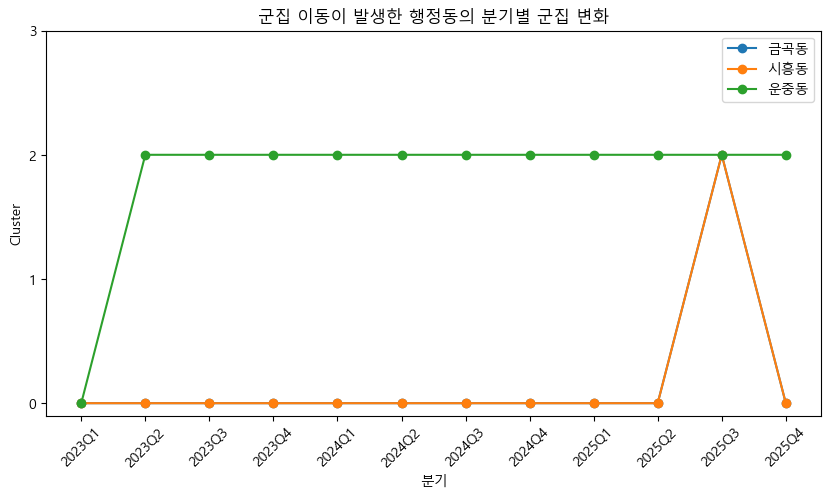

In [122]:
plt.figure(figsize=(10, 5))

for dong in changed_dong_names:
    temp = changed_history[changed_history["adm_dong_nm"] == dong]
    plt.plot(temp["base_quarter"], temp["cluster"], marker="o", label=dong)

plt.title("군집 이동이 발생한 행정동의 분기별 군집 변화")
plt.xlabel("분기")
plt.ylabel("Cluster")
plt.xticks(rotation=45)
plt.yticks([0, 1, 2, 3])
plt.legend()
plt.show()

## 8. 결과 저장

In [123]:
save_columns = [
    "base_quarter",
    "adm_dong_nm",
    "gu",
    *FEATURES,
    "cluster",
    "cluster_label",
]

ml_df[save_columns].to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
OUTPUT_PATH

WindowsPath('../data/ML용_kmeans_result_4vars.csv')

## 최종 해석

K-Means 군집분석 결과, 성남시 행정동-분기 단위 상권은 4개 유형으로 분류되었다. cluster 0은 일반/저활력 상권형, cluster 1은 프랜차이즈 침투 고위험형, cluster 2는 중상위 활성 상권형, cluster 3은 초고활성 대형 상권형으로 해석할 수 있다. 특히 백현동은 프랜차이즈 침투율이 높은 고위험 후보로, 정자1동은 매출 규모가 큰 초고활성 대형 상권으로 구분된다.

In [124]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_score = silhouette_score(X_scaled, ml_df["cluster"])
db_score = davies_bouldin_score(X_scaled, ml_df["cluster"])
ch_score = calinski_harabasz_score(X_scaled, ml_df["cluster"])

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.5610258961809905
Davies-Bouldin Score: 0.6092967917120946
Calinski-Harabasz Score: 687.906852402547


4개 한번에 봤을때 결과값이 막 그렇게 좋지 않아 1개씩 해보는걸로 각각변수를 볼때는 낮음/중간/높음으로 해석할 예정

## 유동인구

In [125]:
# 분기, 행정동,구,유동인구로 필요한컬럼 꺼내서 1개씩 확인
floating_df = ml_df[["base_quarter", "adm_dong_nm", "gu", "floating_pop"]].copy()
floating_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop
0,2023Q1,신흥1동,수정구,781803.43
1,2023Q2,신흥1동,수정구,808998.65
2,2023Q3,신흥1동,수정구,807881.77
3,2023Q4,신흥1동,수정구,860145.94
4,2024Q1,신흥1동,수정구,779105.37


In [126]:
X_floating = floating_df[["floating_pop"]]
X_floating.head()

,floating_pop
0,781803.43
1,808998.65
2,807881.77
3,860145.94
4,779105.37


In [127]:
# 이제 유동인구 넣을 데이터 봤으니 스케일링 실행
scaler_floating = StandardScaler()
X_floating_scaled = scaler_floating.fit_transform(X_floating)

X_floating_scaled[:5]

array([[-0.90597918],
       [-0.89244109],
       [-0.89299709],
       [-0.86697939],
       [-0.90732231]])

스케일링 완료 평균0, 표준편차1 기준으로 바꾼 값 -0.90이면 평균보다 낮은 쪽 스케일링 정상적으로 된거 같음

In [128]:
# 유동인구 기준으로 k-means 실행
kmeans_floating = KMeans(n_clusters=3, random_state= RANDOM_STATE, n_init=10)
floating_df["floating_cluster_raw"] = kmeans_floating.fit_predict(X_floating_scaled)
floating_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop,floating_cluster_raw
0,2023Q1,신흥1동,수정구,781803.43,2
1,2023Q2,신흥1동,수정구,808998.65,2
2,2023Q3,신흥1동,수정구,807881.77,2
3,2023Q4,신흥1동,수정구,860145.94,2
4,2024Q1,신흥1동,수정구,779105.37,2


낮은 유동인구 그룹, 중간, 높음으로 분류만 한거지 다시 재정의 해야됨

In [129]:
floating_order = (floating_df.groupby("floating_cluster_raw"))["floating_pop"].mean().sort_values().index.tolist()
floating_order

[2, 0, 1]

In [130]:
floating_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(floating_order)
}

floating_df["floating_cluster"] = floating_df["floating_cluster_raw"].map(floating_label_map)

floating_df["floating_level"] = floating_df["floating_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

floating_df.head()

,base_quarter,adm_dong_nm,gu,floating_pop,floating_cluster_raw,floating_cluster,floating_level
0,2023Q1,신흥1동,수정구,781803.43,2,0,낮음
1,2023Q2,신흥1동,수정구,808998.65,2,0,낮음
2,2023Q3,신흥1동,수정구,807881.77,2,0,낮음
3,2023Q4,신흥1동,수정구,860145.94,2,0,낮음
4,2024Q1,신흥1동,수정구,779105.37,2,0,낮음


In [131]:
floating_df.groupby("floating_level")["floating_pop"].mean().reindex(["낮음", "중간", "높음"])

floating_level
낮음    1.235445e+06
중간    3.239139e+06
높음    6.736080e+06
Name: floating_pop, dtype: float64

재정의 된 값이 내가 의도한대로 0이 낮음 1이 중간 2가 높음으로 잘 정의 된거 같다.

In [132]:
# 이제 각각 유동인구 그룹이 몇개가 있는지 확인
floating_summary = (
    floating_df.groupby("floating_level")["floating_pop"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(floating_summary)

,count,mean,min,max
floating_level,,,,
낮음,327,1.235445e+06,150045.93,2216297.53
중간,195,3.239139e+06,2259012.01,4891474.15
높음,78,6.736080e+06,5044376.66,11222106.41


유동인구를 단일 변수로 K-Means 군집화한 결과, 전체 600개 행정동-분기 관측치는 유동인구 낮음 327개, 중간 195개, 높음 78개로 구분되었다.

낮음 그룹의 평균 유동인구는 약 123만 명, 중간 그룹은 약 324만 명, 높음 그룹은 약 674만 명으로 나타났다. 이를 통해 행정동별 상권 유입 규모가 세 단계로 구분됨을 확인하였다.

유동인구가 높은 그룹은 방문자 유입이 많은 상권으로 해석할 수 있으나, 유동인구만으로는 실제 소비 활동이나 프랜차이즈화 정도를 판단할 수 없기 때문에 이후 매출액, 매출건수, 프랜차이즈 침투율과 함께 종합적으로 해석할 필요가 있다.

In [133]:
# 이제 유동인구 단일 변수로 군집화가 얼마나 잘 됬는지 silgouette_score 확인
floating_silhouette = silhouette_score(
    X_floating_scaled,
    floating_df["floating_cluster"]
)

print("유동인구 단일 변수 Silhouette Score:", floating_silhouette)

유동인구 단일 변수 Silhouette Score: 0.5905923168740247


유동인구 단일 변수 K-Means는 유동인구 규모를 낮음, 중간, 높음 3개 수준으로 구분하기 위해 k=3으로 설정하였다. 분석 결과 Silhouette Score는 0.591로 나타났으며, 이는 유동인구 기준 군집이 비교적 해석 가능한 수준으로 분리되었음을 의미한다.

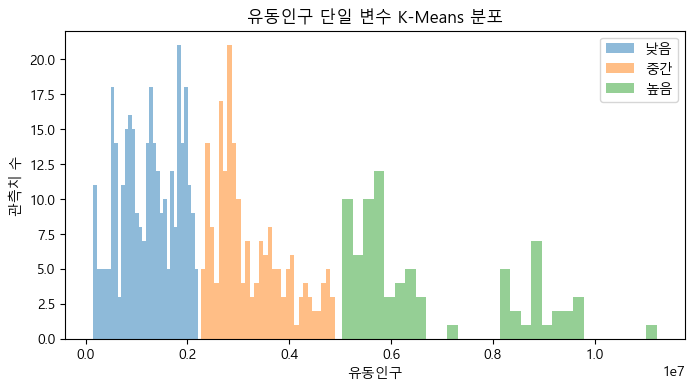

In [134]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = floating_df[floating_df["floating_level"] == level]
    plt.hist(
        temp["floating_pop"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("유동인구 단일 변수 K-Means 분포")
plt.xlabel("유동인구")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

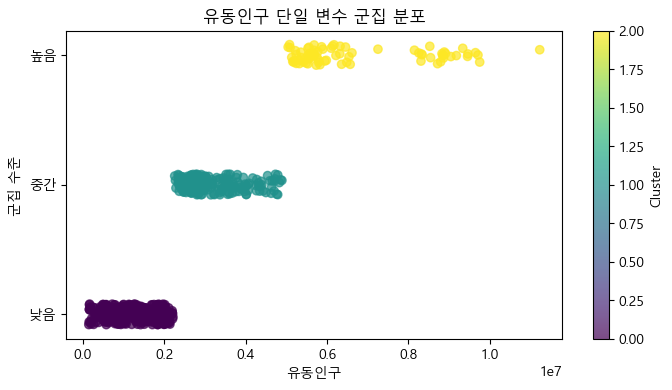

In [135]:
level_to_num = {"낮음": 0, "중간": 1, "높음": 2}

floating_df["floating_level_num"] = floating_df["floating_level"].map(level_to_num)

plt.figure(figsize=(8, 4))

y_jitter = floating_df["floating_level_num"] + np.random.uniform(-0.08, 0.08, len(floating_df))

plt.scatter(
    floating_df["floating_pop"],
    y_jitter,
    c=floating_df["floating_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("유동인구 단일 변수 군집 분포")
plt.xlabel("유동인구")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()

행정동 분기 데이터를 유동인구 기준으로 봤을때 대부분 낮음에서 ~ 중간 그룹에 몰려있고 일부 지역만 높은 그룹으로 분리 되는거 같음

유동인구 단일 변수 K-Means 분포를 확인한 결과, 행정동-분기 관측치는 유동인구 규모에 따라 낮음, 중간, 높음 3개 그룹으로 구분되었다. 낮음 그룹은 가장 많은 관측치를 포함하고 있으며, 중간 그룹은 약 200만~490만 명 수준, 높음 그룹은 약 500만 명 이상의 유동인구를 가진 관측치로 분리되었다.

이를 통해 성남시 행정동별 유동인구 규모가 일부 고유입 상권과 다수의 일반 유입 상권으로 구분됨을 확인할 수 있다. 다만 유동인구는 상권 유입 규모를 나타내는 지표이므로, 젠트리피케이션 위험 여부는 매출액, 매출건수, 프랜차이즈 침투율과 함께 종합적으로 해석할 필요가 있다.

## 매출액

In [136]:
sales_amt_df = ml_df[["base_quarter","adm_dong_nm","gu","sales_amt"]].copy()
sales_amt_df.head()

,base_quarter,adm_dong_nm,gu,sales_amt
0,2023Q1,신흥1동,수정구,2.533850e+10
1,2023Q2,신흥1동,수정구,2.648371e+10
2,2023Q3,신흥1동,수정구,2.583415e+10
3,2023Q4,신흥1동,수정구,2.626346e+10
4,2024Q1,신흥1동,수정구,2.431509e+10


매출액 같은 경우는 한쪽으로 치우치는 경우가 높아 로그변환 후 스케일링(큰값영향 완화)

In [137]:
sales_amt_df["sales_amt_log"] = np.log1p(sales_amt_df["sales_amt"])

sales_amt_df[["sales_amt", "sales_amt_log"]].head()

,sales_amt,sales_amt_log
0,2.533850e+10,23.955591
1,2.648371e+10,23.999796
2,2.583415e+10,23.974963
3,2.626346e+10,23.991444
4,2.431509e+10,23.914363


In [138]:
# k-means에 넣을 x 만들기
X_sales_amt = sales_amt_df[["sales_amt_log"]]
X_sales_amt.head()

,sales_amt_log
0,23.955591
1,23.999796
2,23.974963
3,23.991444
4,23.914363


In [139]:
# 스케일링 실행
scaler_sales_amt = StandardScaler()
X_sales_amt_scaled = scaler_sales_amt.fit_transform(X_sales_amt)

X_sales_amt_scaled[:5]

array([[-0.3741983 ],
       [-0.34869082],
       [-0.36301978],
       [-0.35350975],
       [-0.39798798]])

In [140]:
# 매출액 기준으로 3개 그룹 나누기
kmeans_sales_amt = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_amt_df["sales_amt_cluster_raw"] = kmeans_sales_amt.fit_predict(X_sales_amt_scaled)

sales_amt_df.head()

,base_quarter,adm_dong_nm,gu,sales_amt,sales_amt_log,sales_amt_cluster_raw
0,2023Q1,신흥1동,수정구,2.533850e+10,23.955591,0
1,2023Q2,신흥1동,수정구,2.648371e+10,23.999796,0
2,2023Q3,신흥1동,수정구,2.583415e+10,23.974963,0
3,2023Q4,신흥1동,수정구,2.626346e+10,23.991444,0
4,2024Q1,신흥1동,수정구,2.431509e+10,23.914363,0


무작위로 순위 매긴거라 보정 예정

In [141]:
sales_amt_order = (
    sales_amt_df.groupby("sales_amt_cluster_raw")["sales_amt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_amt_order

[0, 2, 1]

In [142]:
sales_amt_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_amt_order)
}

sales_amt_df["sales_amt_cluster"] = sales_amt_df["sales_amt_cluster_raw"].map(sales_amt_label_map)

sales_amt_df["sales_amt_level"] = sales_amt_df["sales_amt_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_amt_df.head()

,base_quarter,adm_dong_nm,gu,sales_amt,sales_amt_log,sales_amt_cluster_raw,sales_amt_cluster,sales_amt_level
0,2023Q1,신흥1동,수정구,2.533850e+10,23.955591,0,0,낮음
1,2023Q2,신흥1동,수정구,2.648371e+10,23.999796,0,0,낮음
2,2023Q3,신흥1동,수정구,2.583415e+10,23.974963,0,0,낮음
3,2023Q4,신흥1동,수정구,2.626346e+10,23.991444,0,0,낮음
4,2024Q1,신흥1동,수정구,2.431509e+10,23.914363,0,0,낮음


In [143]:
sales_amt_df.groupby("sales_amt_level")["sales_amt"].mean().reindex(["낮음", "중간", "높음"])

sales_amt_level
낮음    2.355927e+10
중간    2.027107e+11
높음    4.035208e+12
Name: sales_amt, dtype: float64

순서대로 보정 잘 된거 같음

In [144]:
sales_amt_summary = (
    sales_amt_df.groupby("sales_amt_level")["sales_amt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_amt_summary)

,count,mean,min,max
sales_amt_level,,,,
낮음,431,2.355927e+10,2.265520e+09,5.659846e+10
중간,104,2.027107e+11,5.941399e+10,5.831210e+11
높음,65,4.035208e+12,6.741808e+11,2.038408e+13


In [145]:
sales_amt_silhouette = silhouette_score(
    X_sales_amt_scaled,
    sales_amt_df["sales_amt_cluster"]
)

print("매출액 단일 변수 Silhouette Score:", sales_amt_silhouette)

매출액 단일 변수 Silhouette Score: 0.6469248594575767


응? 이번에는 유동인구보다는 높게 나왔네...

매출액 단일 변수 K-Means는 매출 규모를 낮음, 중간, 높음 3개 수준으로 구분하기 위해 k=3으로 설정하였다. 매출액은 일부 행정동에서 매우 큰 값을 가지므로 log1p 변환 후 StandardScaler를 적용하였다. 분석 결과 Silhouette Score는 0.647로 나타났으며, 이는 매출액 기준 군집이 유동인구 단일 변수보다 더 뚜렷하게 분리되었음을 의미한다.

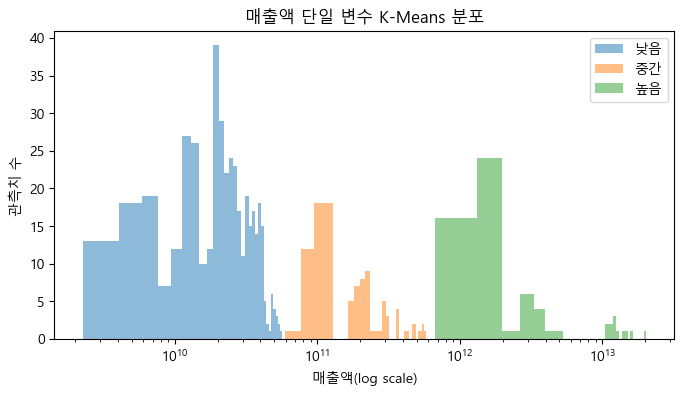

In [146]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_amt_df[sales_amt_df["sales_amt_level"] == level]
    plt.hist(
        temp["sales_amt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.xscale("log")
plt.title("매출액 단일 변수 K-Means 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

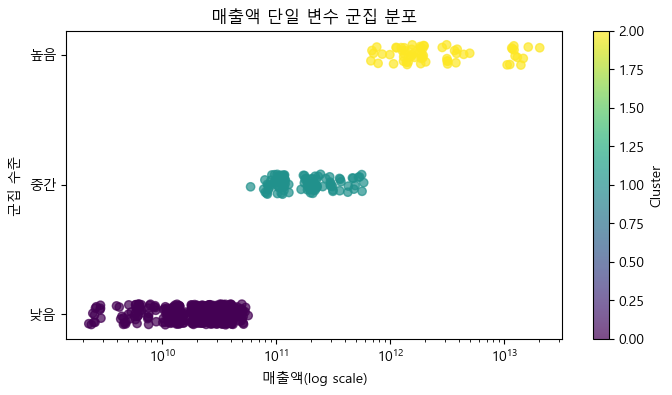

In [147]:
sales_amt_df["sales_amt_level_num"] = sales_amt_df["sales_amt_level"].map(level_to_num)

plt.figure(figsize=(8, 4))

y_jitter = sales_amt_df["sales_amt_level_num"] + np.random.uniform(-0.08, 0.08, len(sales_amt_df))

plt.scatter(
    sales_amt_df["sales_amt"],
    y_jitter,
    c=sales_amt_df["sales_amt_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("매출액 단일 변수 군집 분포")
plt.xlabel("매출액(log scale)")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()

매출액 단일 변수 K-Means 분포를 확인한 결과, 행정동-분기 관측치는 매출 규모에 따라 낮음, 중간, 높음 3개 그룹으로 구분되었다.

매출액은 값의 범위가 매우 크고 일부 행정동에서 극단적으로 높은 값을 보일 수 있으므로, log1p 변환 후 StandardScaler를 적용하여 K-Means를 수행하였다.

분석 결과 매출액 낮음 그룹이 가장 많은 관측치를 차지했으며, 중간 그룹과 높음 그룹은 상대적으로 적은 관측치로 분리되었다. 특히 매출액 높음 그룹은 다른 그룹보다 소비 규모가 확연히 큰 상권으로 해석할 수 있다.

매출액 단일 변수 Silhouette Score는 0.647로 나타나, 매출액 기준 낮음·중간·높음 군집이 비교적 명확하게 분리되었음을 확인하였다.

오케이 남은것도 이렇게 진행

## 매출건수

In [148]:
sales_cnt_df = ml_df[
    [
        "base_quarter",
        "adm_dong_nm",
        "gu",
        "sales_cnt"
    ]
].copy()

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt
0,2023Q1,신흥1동,수정구,999168.0
1,2023Q2,신흥1동,수정구,1092318.0
2,2023Q3,신흥1동,수정구,1113248.0
3,2023Q4,신흥1동,수정구,1072653.0
4,2024Q1,신흥1동,수정구,1043582.0


In [149]:
X_sales_cnt = sales_cnt_df[["sales_cnt"]]

X_sales_cnt.head()

,sales_cnt
0,999168.0
1,1092318.0
2,1113248.0
3,1072653.0
4,1043582.0


In [150]:
scaler_sales_cnt = StandardScaler()
X_sales_cnt_scaled = scaler_sales_cnt.fit_transform(X_sales_cnt)

X_sales_cnt_scaled[:5]

array([[-0.25384463],
       [-0.2512732 ],
       [-0.25069542],
       [-0.25181606],
       [-0.25261857]])

In [151]:
kmeans_sales_cnt = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_cluster_raw"] = kmeans_sales_cnt.fit_predict(X_sales_cnt_scaled)

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw
0,2023Q1,신흥1동,수정구,999168.0,0
1,2023Q2,신흥1동,수정구,1092318.0,0
2,2023Q3,신흥1동,수정구,1113248.0,0
3,2023Q4,신흥1동,수정구,1072653.0,0
4,2024Q1,신흥1동,수정구,1043582.0,0


In [152]:
sales_cnt_order = (
    sales_cnt_df.groupby("sales_cnt_cluster_raw")["sales_cnt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_order

[0, 1, 2]

In [153]:
sales_cnt_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_order)
}

sales_cnt_df["sales_cnt_cluster"] = sales_cnt_df["sales_cnt_cluster_raw"].map(sales_cnt_label_map)

sales_cnt_df["sales_cnt_level"] = sales_cnt_df["sales_cnt_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level
0,2023Q1,신흥1동,수정구,999168.0,0,0,낮음
1,2023Q2,신흥1동,수정구,1092318.0,0,0,낮음
2,2023Q3,신흥1동,수정구,1113248.0,0,0,낮음
3,2023Q4,신흥1동,수정구,1072653.0,0,0,낮음
4,2024Q1,신흥1동,수정구,1043582.0,0,0,낮음


In [154]:
sales_cnt_df.groupby("sales_cnt_level")["sales_cnt"].mean().reindex(["낮음", "중간", "높음"])

sales_cnt_level
낮음    3.378809e+06
중간    1.196821e+08
높음    2.278689e+08
Name: sales_cnt, dtype: float64

In [155]:
sales_cnt_summary = (
    sales_cnt_df.groupby("sales_cnt_level")["sales_cnt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_summary)

,count,mean,min,max
sales_cnt_level,,,,
낮음,576,3.378809e+06,130660.0,45365941.0
중간,12,1.196821e+08,93584450.0,154787492.0
높음,12,2.278689e+08,185707003.0,337137603.0


In [156]:
sales_cnt_silhouette = silhouette_score(
    X_sales_cnt_scaled,
    sales_cnt_df["sales_cnt_cluster"]
)

print("매출건수 단일 변수 Silhouette Score:", sales_cnt_silhouette)

매출건수 단일 변수 Silhouette Score: 0.9466883405181302


스코어 점수가 0.94로 엄청 높게나와서 어떤 행정동이 있는지 확인

In [157]:
sales_cnt_df[sales_cnt_df["sales_cnt_level"].isin(["중간", "높음"])][
    ["base_quarter", "adm_dong_nm", "gu", "sales_cnt", "sales_cnt_level"]
].sort_values(["sales_cnt_level", "adm_dong_nm", "base_quarter"])

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_level
396,2023Q1,정자1동,분당구,203895359.0,높음
397,2023Q2,정자1동,분당구,213976516.0,높음
398,2023Q3,정자1동,분당구,210762539.0,높음
399,2023Q4,정자1동,분당구,209161641.0,높음
400,2024Q1,정자1동,분당구,185707003.0,높음
401,2024Q2,정자1동,분당구,209792426.0,높음
402,2024Q3,정자1동,분당구,210424560.0,높음
403,2024Q4,정자1동,분당구,213702486.0,높음
404,2025Q1,정자1동,분당구,226973470.0,높음
405,2025Q2,정자1동,분당구,242511134.0,높음


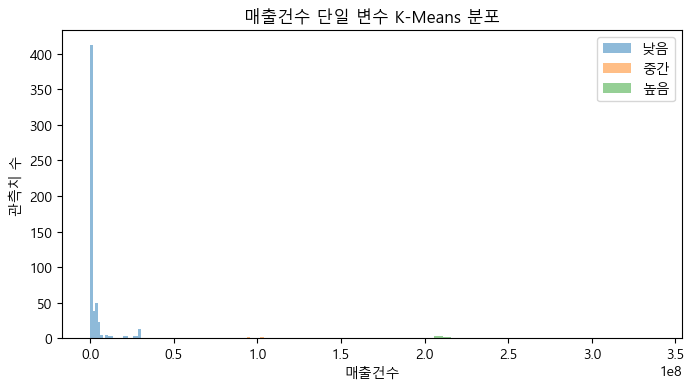

In [158]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_level"] == level]
    plt.hist(
        temp["sales_cnt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("매출건수 단일 변수 K-Means 분포")
plt.xlabel("매출건수")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

아 이거는 건수가 너무 높은게 나와서 log변환 후 한번더 확인해봐야할 문제인듯.... 일단 예측률은 좋음... 차이가 너무 극심하다...

In [159]:
# 로그 변환
sales_cnt_df["sales_cnt_log"] = np.log1p(sales_cnt_df["sales_cnt"])

sales_cnt_df[["sales_cnt", "sales_cnt_log"]].head()

,sales_cnt,sales_cnt_log
0,999168.0,13.814679
1,1092318.0,13.903814
2,1113248.0,13.922793
3,1072653.0,13.885647
4,1043582.0,13.858171


In [160]:
X_sales_cnt_log = sales_cnt_df[["sales_cnt_log"]]

X_sales_cnt_log.head()

,sales_cnt_log
0,13.814679
1,13.903814
2,13.922793
3,13.885647
4,13.858171


In [161]:
scaler_sales_cnt_log = StandardScaler()
X_sales_cnt_log_scaled = scaler_sales_cnt_log.fit_transform(X_sales_cnt_log)

X_sales_cnt_log_scaled[:5]

array([[-0.39186412],
       [-0.33005302],
       [-0.31689128],
       [-0.34265112],
       [-0.36170461]])

In [162]:
kmeans_sales_cnt_log = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_log_cluster_raw"] = kmeans_sales_cnt_log.fit_predict(
    X_sales_cnt_log_scaled
)

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw
0,2023Q1,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0
1,2023Q2,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0
2,2023Q3,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0
3,2023Q4,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0
4,2024Q1,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0


In [163]:
sales_cnt_log_order = (
    sales_cnt_df.groupby("sales_cnt_log_cluster_raw")["sales_cnt"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_log_order

[0, 2, 1]

In [164]:
sales_cnt_log_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_log_order)
}

sales_cnt_df["sales_cnt_log_cluster"] = sales_cnt_df["sales_cnt_log_cluster_raw"].map(
    sales_cnt_log_label_map
)

sales_cnt_df["sales_cnt_log_level"] = sales_cnt_df["sales_cnt_log_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level
0,2023Q1,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음
1,2023Q2,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음
2,2023Q3,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음
3,2023Q4,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음
4,2024Q1,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음


In [165]:
sales_cnt_df.groupby("sales_cnt_log_level")["sales_cnt"].mean().reindex(["낮음", "중간", "높음"])

sales_cnt_log_level
낮음    9.774944e+05
중간    5.157127e+06
높음    8.698984e+07
Name: sales_cnt, dtype: float64

순서대로 잘 되었음

In [166]:
sales_cnt_log_summary = (
    sales_cnt_df.groupby("sales_cnt_log_level")["sales_cnt"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_log_summary)

,count,mean,min,max
sales_cnt_log_level,,,,
낮음,432,9.774944e+05,130660.0,1934371.0
중간,109,5.157127e+06,2147996.0,12914486.0
높음,59,8.698984e+07,18623598.0,337137603.0


| 매출건수 수준 | count |    평균 매출건수 | 범위                 |
| ------- | ----: | ---------: | ------------------ |
| 낮음      |  432개 |  약 97.7만 건 | 13만 ~ 193만         |
| 중간      |  109개 | 약 515.7만 건 | 214만 ~ 1,291만      |
| 높음      |   59개 | 약 8,699만 건 | 1,862만 ~ 3억 3,713만 |


매출건수는 원본값 기준으로 분석할 경우 일부 초대형 상권의 영향이 지나치게 커서 대부분의 관측치가 낮음 그룹에 몰리는 문제가 있었다. 따라서 log1p 변환 후 K-Means를 다시 수행하였고, 그 결과 낮음 432개, 중간 109개, 높음 59개로 보다 균형 있게 군집이 구분되었다.

In [167]:
sales_cnt_log_silhouette = silhouette_score(
    X_sales_cnt_log_scaled,
    sales_cnt_df["sales_cnt_log_cluster"]
)

print("매출건수 로그변환 단일 변수 Silhouette Score:", sales_cnt_log_silhouette)

매출건수 로그변환 단일 변수 Silhouette Score: 0.6289449072466531


아 확실히 로그 변환하고 보니 스코어가 확연히 차이가 난다...

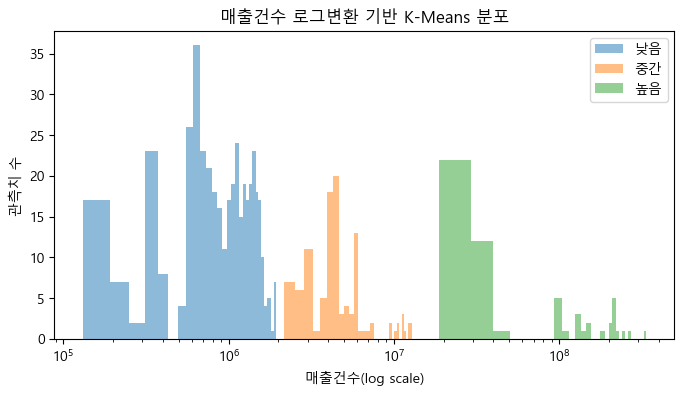

In [168]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_log_level"] == level]
    plt.hist(
        temp["sales_cnt"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.xscale("log")
plt.title("매출건수 로그변환 기반 K-Means 분포")
plt.xlabel("매출건수(log scale)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

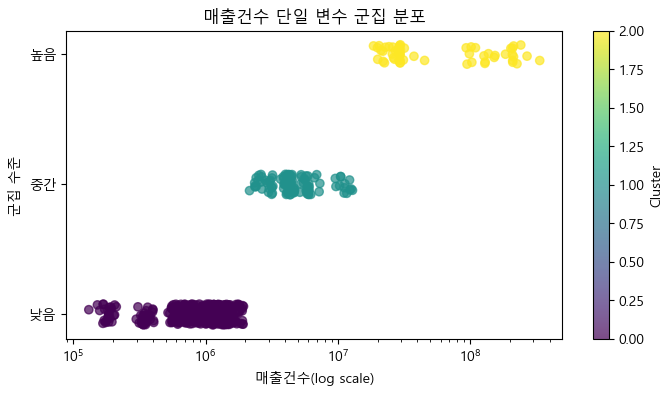

In [169]:
sales_cnt_df["sales_cnt_log_level_num"] = sales_cnt_df["sales_cnt_log_level"].map(level_to_num)

plt.figure(figsize=(8, 4))

y_jitter = sales_cnt_df["sales_cnt_log_level_num"] + np.random.uniform(-0.08, 0.08, len(sales_cnt_df))

plt.scatter(
    sales_cnt_df["sales_cnt"],
    y_jitter,
    c=sales_cnt_df["sales_cnt_log_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.xscale("log")
plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("매출건수 단일 변수 군집 분포")
plt.xlabel("매출건수(log scale)")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()

아... 확실히 값차이가 심한 변수들은 로그변환하고 보면 차이가 난다.... 해석은 원본값으로 하는게 맞는거 같고...

| 기준      |   낮음 |  중간 |  높음 |
| ------- | ---: | --: | --: |
| 원본 매출건수 | 576개 | 12개 | 12개 |


log 변환 후
| 매출건수 수준 | 관측치 수 |    평균 매출건수 | 해석                 |
| ------- | ----: | ---------: | ------------------ |
| 낮음      |  432개 |  약 97.7만 건 | 일반적인 소비 빈도 상권      |
| 중간      |  109개 | 약 515.7만 건 | 소비 빈도가 높은 중상위 상권   |
| 높음      |   59개 | 약 8,699만 건 | 소비 빈도가 매우 높은 대형 상권 |


매출건수는 실제 소비가 발생한 빈도를 나타내는 지표이다. 원본 매출건수 기준으로 K-Means를 수행했을 때는 일부 초대형 상권의 영향으로 대부분의 관측치가 낮음 그룹에 몰리고, 중간·높음 그룹은 각각 12개 관측치만 포함되는 극단적인 결과가 나타났다.

이에 따라 극단값의 영향을 완화하기 위해 매출건수에 log1p 변환을 적용한 후 StandardScaler로 표준화하여 K-Means를 다시 수행하였다.

로그변환 기반 K-Means 결과, 전체 600개 관측치는 낮음 432개, 중간 109개, 높음 59개로 구분되었다. 낮음 그룹의 평균 매출건수는 약 97.7만 건, 중간 그룹은 약 515.7만 건, 높음 그룹은 약 8,699만 건으로 나타났다.

Silhouette Score는 0.629로 나타났다. 이는 원본값 기준보다 낮아졌지만, 일부 극단값에 의해 군집이 과도하게 분리되는 문제를 완화하고 전체 분포를 더 균형 있게 구분한 결과로 해석할 수 있다.

따라서 매출건수 단일 변수 분석에서는 로그변환 기반 군집 결과를 중심으로 해석하는 것이 적절하다.

### 매출건수 비율로 확인

In [170]:
sales_cnt_df["sales_cnt_ratio"] = (
    sales_cnt_df["sales_cnt"] / 
    sales_cnt_df.groupby("base_quarter")["sales_cnt"].transform("sum")
)

sales_cnt_df["sales_cnt_ratio_pct"] = sales_cnt_df["sales_cnt_ratio"] * 100

sales_cnt_df[
    [
        "base_quarter",
        "adm_dong_nm",
        "gu",
        "sales_cnt",
        "sales_cnt_ratio",
        "sales_cnt_ratio_pct"
    ]
].head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_ratio,sales_cnt_ratio_pct
0,2023Q1,신흥1동,수정구,999168.0,0.002231,0.223103
1,2023Q2,신흥1동,수정구,1092318.0,0.002306,0.230585
2,2023Q3,신흥1동,수정구,1113248.0,0.002348,0.234826
3,2023Q4,신흥1동,수정구,1072653.0,0.002280,0.227967
4,2024Q1,신흥1동,수정구,1043582.0,0.002475,0.247516


In [171]:
sales_cnt_df.groupby("base_quarter")["sales_cnt"].transform("sum")

0      447851162.0
1      473716365.0
2      474073242.0
3      470530494.0
4      421621497.0
5      481716756.0
6      501954326.0
7      502917414.0
8      513472343.0
9      542830370.0
10     604616888.0
11     681504352.0
12     447851162.0
13     473716365.0
14     474073242.0
15     470530494.0
16     421621497.0
17     481716756.0
18     501954326.0
19     502917414.0
20     513472343.0
21     542830370.0
22     604616888.0
23     681504352.0
24     447851162.0
25     473716365.0
26     474073242.0
27     470530494.0
28     421621497.0
29     481716756.0
30     501954326.0
31     502917414.0
32     513472343.0
33     542830370.0
34     604616888.0
35     681504352.0
36     447851162.0
37     473716365.0
38     474073242.0
39     470530494.0
40     421621497.0
41     481716756.0
42     501954326.0
43     502917414.0
44     513472343.0
45     542830370.0
46     604616888.0
47     681504352.0
48     447851162.0
49     473716365.0
50     474073242.0
51     470530494.0
52     42162

In [172]:
sales_cnt_df["sales_cnt_ratio_pct"].describe()

count    600.000000
mean       2.000000
std        6.990740
min        0.023150
25%        0.146227
50%        0.245845
75%        0.617410
max       49.469619
Name: sales_cnt_ratio_pct, dtype: float64

In [173]:
X_sales_cnt_ratio = sales_cnt_df[["sales_cnt_ratio_pct"]]

X_sales_cnt_ratio.head()

,sales_cnt_ratio_pct
0,0.223103
1,0.230585
2,0.234826
3,0.227967
4,0.247516


In [174]:
scaler_sales_cnt_ratio = StandardScaler()
X_sales_cnt_ratio_scaled = scaler_sales_cnt_ratio.fit_transform(X_sales_cnt_ratio)

X_sales_cnt_ratio_scaled[:5]

array([[-0.25439079],
       [-0.25331961],
       [-0.25271239],
       [-0.25369443],
       [-0.2508956 ]])

In [175]:
kmeans_sales_cnt_ratio = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

sales_cnt_df["sales_cnt_ratio_cluster_raw"] = kmeans_sales_cnt_ratio.fit_predict(
    X_sales_cnt_ratio_scaled
)

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level,sales_cnt_log_level_num,sales_cnt_ratio,sales_cnt_ratio_pct,sales_cnt_ratio_cluster_raw
0,2023Q1,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음,0,0.002231,0.223103,0
1,2023Q2,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음,0,0.002306,0.230585,0
2,2023Q3,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음,0,0.002348,0.234826,0
3,2023Q4,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음,0,0.002280,0.227967,0
4,2024Q1,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음,0,0.002475,0.247516,0


In [176]:
sales_cnt_ratio_order = (
    sales_cnt_df.groupby("sales_cnt_ratio_cluster_raw")["sales_cnt_ratio_pct"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

sales_cnt_ratio_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(sales_cnt_ratio_order)
}

sales_cnt_df["sales_cnt_ratio_cluster"] = sales_cnt_df[
    "sales_cnt_ratio_cluster_raw"
].map(sales_cnt_ratio_label_map)

sales_cnt_df["sales_cnt_ratio_level"] = sales_cnt_df[
    "sales_cnt_ratio_cluster"
].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

sales_cnt_df.head()

,base_quarter,adm_dong_nm,gu,sales_cnt,sales_cnt_cluster_raw,sales_cnt_cluster,sales_cnt_level,sales_cnt_log,sales_cnt_log_cluster_raw,sales_cnt_log_cluster,sales_cnt_log_level,sales_cnt_log_level_num,sales_cnt_ratio,sales_cnt_ratio_pct,sales_cnt_ratio_cluster_raw,sales_cnt_ratio_cluster,sales_cnt_ratio_level
0,2023Q1,신흥1동,수정구,999168.0,0,0,낮음,13.814679,0,0,낮음,0,0.002231,0.223103,0,0,낮음
1,2023Q2,신흥1동,수정구,1092318.0,0,0,낮음,13.903814,0,0,낮음,0,0.002306,0.230585,0,0,낮음
2,2023Q3,신흥1동,수정구,1113248.0,0,0,낮음,13.922793,0,0,낮음,0,0.002348,0.234826,0,0,낮음
3,2023Q4,신흥1동,수정구,1072653.0,0,0,낮음,13.885647,0,0,낮음,0,0.002280,0.227967,0,0,낮음
4,2024Q1,신흥1동,수정구,1043582.0,0,0,낮음,13.858171,0,0,낮음,0,0.002475,0.247516,0,0,낮음


In [177]:
sales_cnt_df.groupby("sales_cnt_ratio_level")["sales_cnt_ratio_pct"].mean().reindex(
    ["낮음", "중간", "높음"]
)

sales_cnt_ratio_level
낮음     0.667803
중간    23.388284
높음    44.557164
Name: sales_cnt_ratio_pct, dtype: float64

In [178]:
sales_cnt_ratio_summary = (
    sales_cnt_df.groupby("sales_cnt_ratio_level")["sales_cnt_ratio_pct"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(sales_cnt_ratio_summary)

,count,mean,min,max
sales_cnt_ratio_level,,,,
낮음,576,0.667803,0.023150,7.019039
중간,12,23.388284,20.893369,25.831531
높음,12,44.557164,41.921057,49.469619


In [179]:
sales_cnt_ratio_silhouette = silhouette_score(
    X_sales_cnt_ratio_scaled,
    sales_cnt_df["sales_cnt_ratio_cluster"]
)

print("매출건수 비율 단일 변수 Silhouette Score:", sales_cnt_ratio_silhouette)

매출건수 비율 단일 변수 Silhouette Score: 0.9551217410173998


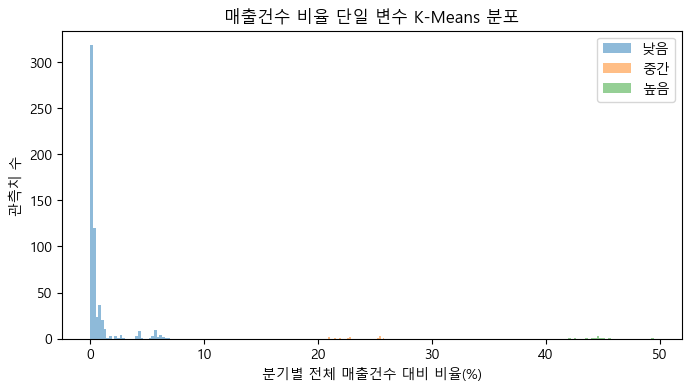

In [180]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = sales_cnt_df[sales_cnt_df["sales_cnt_ratio_level"] == level]
    plt.hist(
        temp["sales_cnt_ratio_pct"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("매출건수 비율 단일 변수 K-Means 분포")
plt.xlabel("분기별 전체 매출건수 대비 비율(%)")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

## 프랜차이즈 침투율

In [181]:
franchise_df = ml_df[
    [
        "base_quarter",
        "adm_dong_nm",
        "gu",
        "franchise_ratio"
    ]
].copy()

franchise_df.head()

,base_quarter,adm_dong_nm,gu,franchise_ratio
0,2023Q1,신흥1동,수정구,4.893482
1,2023Q2,신흥1동,수정구,4.843364
2,2023Q3,신흥1동,수정구,5.156809
3,2023Q4,신흥1동,수정구,5.164021
4,2024Q1,신흥1동,수정구,5.277544


In [182]:
X_franchise = franchise_df[["franchise_ratio"]]

X_franchise.head()

,franchise_ratio
0,4.893482
1,4.843364
2,5.156809
3,5.164021
4,5.277544


In [183]:
scaler_franchise = StandardScaler()
X_franchise_scaled = scaler_franchise.fit_transform(X_franchise)

X_franchise_scaled[:5]

array([[-0.5054022 ],
       [-0.52543237],
       [-0.40016277],
       [-0.39728044],
       [-0.35191059]])

In [184]:
kmeans_franchise = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10
)

franchise_df["franchise_cluster_raw"] = kmeans_franchise.fit_predict(X_franchise_scaled)

franchise_df.head()

,base_quarter,adm_dong_nm,gu,franchise_ratio,franchise_cluster_raw
0,2023Q1,신흥1동,수정구,4.893482,1
1,2023Q2,신흥1동,수정구,4.843364,1
2,2023Q3,신흥1동,수정구,5.156809,1
3,2023Q4,신흥1동,수정구,5.164021,1
4,2024Q1,신흥1동,수정구,5.277544,1


In [185]:
franchise_order = (
    franchise_df.groupby("franchise_cluster_raw")["franchise_ratio"]
    .mean()
    .sort_values()
    .index
    .tolist()
)

franchise_order

[1, 0, 2]

In [186]:
franchise_label_map = {
    old_label: new_label
    for new_label, old_label in enumerate(franchise_order)
}

franchise_df["franchise_cluster"] = franchise_df["franchise_cluster_raw"].map(franchise_label_map)

franchise_df["franchise_level"] = franchise_df["franchise_cluster"].map({
    0: "낮음",
    1: "중간",
    2: "높음"
})

franchise_df.head()

,base_quarter,adm_dong_nm,gu,franchise_ratio,franchise_cluster_raw,franchise_cluster,franchise_level
0,2023Q1,신흥1동,수정구,4.893482,1,0,낮음
1,2023Q2,신흥1동,수정구,4.843364,1,0,낮음
2,2023Q3,신흥1동,수정구,5.156809,1,0,낮음
3,2023Q4,신흥1동,수정구,5.164021,1,0,낮음
4,2024Q1,신흥1동,수정구,5.277544,1,0,낮음


In [187]:
franchise_df.groupby("franchise_level")["franchise_ratio"].mean().reindex(["낮음", "중간", "높음"])

franchise_level
낮음     4.521248
중간     7.141665
높음    13.308931
Name: franchise_ratio, dtype: float64

In [188]:
franchise_summary = (
    franchise_df.groupby("franchise_level")["franchise_ratio"]
    .agg(count="count", mean="mean", min="min", max="max")
    .reindex(["낮음", "중간", "높음"])
)

display(franchise_summary)

,count,mean,min,max
franchise_level,,,,
낮음,317,4.521248,2.362056,5.825769
중간,244,7.141665,5.858271,9.957168
높음,39,13.308931,10.287420,18.465444


침투율은 군집이 잘 되있는거 같음.. 낮음 중간 높음 수가 

In [189]:
franchise_silhouette = silhouette_score(
    X_franchise_scaled,
    franchise_df["franchise_cluster"]
)

print("프랜차이즈 침투율 단일 변수 Silhouette Score:", franchise_silhouette)

프랜차이즈 침투율 단일 변수 Silhouette Score: 0.5882859530737554


아... 점수가 생각보다 안높네...

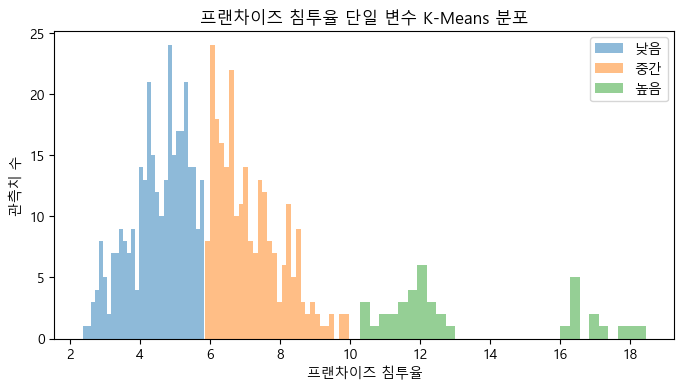

In [190]:
plt.figure(figsize=(8, 4))

for level in ["낮음", "중간", "높음"]:
    temp = franchise_df[franchise_df["franchise_level"] == level]
    plt.hist(
        temp["franchise_ratio"],
        bins=30,
        alpha=0.5,
        label=level
    )

plt.title("프랜차이즈 침투율 단일 변수 K-Means 분포")
plt.xlabel("프랜차이즈 침투율")
plt.ylabel("관측치 수")
plt.legend()
plt.show()

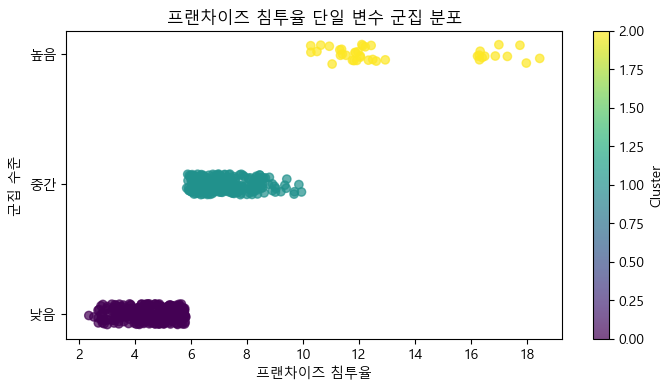

In [191]:
franchise_df["franchise_level_num"] = franchise_df["franchise_level"].map(level_to_num)

plt.figure(figsize=(8, 4))

y_jitter = franchise_df["franchise_level_num"] + np.random.uniform(-0.08, 0.08, len(franchise_df))

plt.scatter(
    franchise_df["franchise_ratio"],
    y_jitter,
    c=franchise_df["franchise_level_num"],
    cmap="viridis",
    alpha=0.7
)

plt.yticks([0, 1, 2], ["낮음", "중간", "높음"])
plt.title("프랜차이즈 침투율 단일 변수 군집 분포")
plt.xlabel("프랜차이즈 침투율")
plt.ylabel("군집 수준")
plt.colorbar(label="Cluster")
plt.show()

프랜차이즈 침투율을 단일 변수로 K-Means 군집화한 결과, 전체 600개 행정동-분기 관측치는 낮음 317개, 중간 244개, 높음 39개로 구분되었다.

낮음 그룹의 평균 프랜차이즈 침투율은 약 4.52, 중간 그룹은 약 7.14, 높음 그룹은 약 13.31로 나타났다. 이는 프랜차이즈 침투율이 낮은 일반 상권, 중간 수준의 프랜차이즈화 상권, 프랜차이즈 침투율이 높은 상권으로 구분됨을 의미한다.

Silhouette Score는 0.588로 나타나 군집 분리가 매우 강하다고 보기는 어렵지만, 낮음·중간·높음 수준으로 해석 가능한 정도의 구분은 확인되었다.

프랜차이즈 침투율이 높은 그룹은 로컬 상권보다 프랜차이즈 중심 상권으로 변화했을 가능성이 있는 지역으로 볼 수 있으며, 젠트리피케이션 위험 후보를 판단할 때 중요한 보조 지표로 활용할 수 있다.

In [192]:
franchise_df[franchise_df["franchise_level"] == "높음"][
    ["base_quarter", "adm_dong_nm", "gu", "franchise_ratio", "franchise_level"]
].sort_values(["adm_dong_nm", "base_quarter"])

,base_quarter,adm_dong_nm,gu,franchise_ratio,franchise_level
540,2023Q1,백현동,분당구,17.006677,높음
541,2023Q2,백현동,분당구,17.310596,높음
542,2023Q3,백현동,분당구,17.759444,높음
543,2023Q4,백현동,분당구,17.986600,높음
544,2024Q1,백현동,분당구,18.465444,높음
545,2024Q2,백현동,분당구,16.879401,높음
546,2024Q3,백현동,분당구,16.501742,높음
547,2024Q4,백현동,분당구,16.409594,높음
548,2025Q1,백현동,분당구,16.313616,높음
549,2025Q2,백현동,분당구,16.305572,높음


In [193]:
franchise_df[franchise_df["franchise_level"] == "높음"] \
    .groupby("adm_dong_nm") \
    .size() \
    .reset_index(name="count") \
    .sort_values("count", ascending=False)

,adm_dong_nm,count
0,백현동,12
1,서현1동,12
2,수내1동,12
3,정자1동,3


| 행정동  | 높음 그룹 포함 횟수 |
| ---- | ----------: |
| 백현동  |          12 |
| 서현1동 |          12 |
| 수내1동 |          12 |
| 정자1동 |           3 |


프랜차이즈 침투율 단일 변수 K-Means 결과, 높음 그룹에는 백현동, 서현1동, 수내1동이 각각 12개 분기 모두 포함되었고, 정자1동은 3개 분기만 포함되었다.

이는 백현동, 서현1동, 수내1동이 분석 기간 동안 지속적으로 프랜차이즈 침투율이 높은 상권임을 의미한다. 따라서 해당 지역들은 로컬 상권 대비 프랜차이즈화 정도가 높은 지역으로 해석할 수 있다.

반면 정자1동은 매출액과 매출건수 측면에서는 초고활성 대형 상권으로 나타났지만, 프랜차이즈 침투율 기준으로는 일부 분기만 높은 그룹에 포함되었다. 따라서 정자1동은 프랜차이즈 침투형보다는 매출 규모가 압도적으로 큰 대형 상권으로 구분하는 것이 적절하다.

In [194]:
franchise_df[
    (franchise_df["adm_dong_nm"] == "정자1동") &
    (franchise_df["franchise_level"] == "높음")
][
    ["base_quarter", "adm_dong_nm", "gu", "franchise_ratio", "franchise_level"]
]

,base_quarter,adm_dong_nm,gu,franchise_ratio,franchise_level
401,2024Q2,정자1동,분당구,10.510315,높음
402,2024Q3,정자1동,분당구,10.287420,높음
403,2024Q4,정자1동,분당구,10.292675,높음


아 정자1동이 24 2분기부터 4분까지 침투율이 높음으로 들어가있네...

정자1동은 프랜차이즈 침투율 기준으로 2024Q2, 2024Q3, 2024Q4 총 3개 분기에서만 높음 그룹에 포함되었다. 이는 정자1동이 분석 기간 전체에 걸쳐 지속적으로 프랜차이즈 침투율이 높은 지역이라기보다는, 2024년 중반 이후 일부 기간에 프랜차이즈 침투율이 높아진 지역인거 같은데....

In [195]:
franchise_df[
    franchise_df["adm_dong_nm"].isin(["백현동", "서현1동", "수내1동", "정자1동"])
][
    ["base_quarter", "adm_dong_nm", "franchise_ratio", "franchise_level"]
].sort_values(["adm_dong_nm", "base_quarter"])

,base_quarter,adm_dong_nm,franchise_ratio,franchise_level
540,2023Q1,백현동,17.006677,높음
541,2023Q2,백현동,17.310596,높음
542,2023Q3,백현동,17.759444,높음
543,2023Q4,백현동,17.986600,높음
544,2024Q1,백현동,18.465444,높음
545,2024Q2,백현동,16.879401,높음
546,2024Q3,백현동,16.501742,높음
547,2024Q4,백현동,16.409594,높음
548,2025Q1,백현동,16.313616,높음
549,2025Q2,백현동,16.305572,높음


- 정자1동: 초고활성 대형 상권
- 백현동: 프랜차이즈 침투 위험 후보
- 서현1동·수내1동: 프랜차이즈화 관찰 지역
- 운중동: 중상위 활성 상권으로 전환
- 금곡동·시흥동: 일시적 활성화